Cell 1: The IntuitionThe Taylor Series allows us to take a complicated, non-linear function (like $\sin(x)$, $\cos(x)$, or $e^x$) and rebuild it as a simple, predictable polynomial (a sum of terms like $x, x^2, x^3$).Imagine looking at a curve near a specific anchor point ($x = a$).To guess its path using a straight line, we match the function's value and its slope (1st derivative) at that spot.To capture the bend, we add a quadratic term ($x^2$) to match the curvature (2nd derivative).By continuously adding higher-order derivatives, our polynomial matches the true curve over a wider area, expanding outward from the anchor point.2. The General Mathematical FormulaThe infinite Taylor series of a smooth function $f(x)$ centered around an anchor point $a$ is defined as:$$f(x) = f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \dots = \sum_{n=0}^{\infty} \frac{f^{(n)}(a)}{n!}(x-a)^n$$Note: When we center our approximation exactly at $a = 0$, it is called a Maclaurin Series.


In [1]:
# =============================================================================
# NOTEBOOK STEP 1: ENVIRONMENT SETUP
# We import high-performance numerical engines and visualization toolkits.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import math

# Configure professional publication styling parameters for high-contrast dark mode
plt.rcParams.update({
    'font.size': 12,
    'axes.linewidth': 2,
    'figure.figsize': (12, 7),
    'lines.linewidth': 2.5
})

print("✅ Setup complete. Libraries imported successfully.")

✅ Setup complete. Libraries imported successfully.


Step-by-Step Analytical Derivation for $f(x) = \sin(x)$Let's unpack the math behind a sine wave approximation centered at $a = 0$:Evaluate the function and its higher-order derivatives at $x = 0$:$f(x) = \sin(x) \implies f(0) = \sin(0) = \mathbf{0}$$f'(x) = \cos(x) \implies f'(0) = \cos(0) = \mathbf{1}$$f''(x) = -\sin(x) \implies f''(0) = -\sin(0) = \mathbf{0}$$f'''(x) = -\cos(x) \implies f'''(0) = -\cos(0) = \mathbf{-1}$$f^{(4)}(x) = \sin(x) \implies f^{(4)}(0) = \sin(0) = \mathbf{0}$$f^{(5)}(x) = \cos(x) \implies f^{(5)}(0) = \cos(0) = \mathbf{1}$Plug these coefficient values back into our main formula:$$\sin(x) = 0 + 1(x) + \frac{0}{2!}x^2 + \frac{-1}{3!}x^3 + \frac{0}{4!}x^4 + \frac{1}{5!}x^5 - \frac{1}{7!}x^7 + \dots$$Simplify to reveal the final alternating odd-powered terms:$$\sin(x) = x - \frac{x^3}{3!} + \frac{x^5}{5!} - \frac{x^7}{7!} + \frac{x^9}{9!} - \dots$$


In [2]:
# =============================================================================
# NOTEBOOK STEP 2: ARRAY PARAMETERIZATION & POLYNOMIAL DEFINITIONS
# =============================================================================

# Create a dense grid space vector from -10 to +10 containing 2000 steps
x = np.linspace(-10, 10, 2000)

# Calculate the ground truth analytical reference wave
y_true = np.sin(x)

# -----------------------------------------------------------------------------
# Explicitly compute each polynomial expansion order discovered in our math cell
# -----------------------------------------------------------------------------

# Linear Vector (1st Order approximation: straight tangent line)
y_1 = x

# Cubic Vector (3rd Order approximation: introduces basic local bending)
y_3 = x - (x**3) / math.factorial(3)

# Quintic Vector (5th Order approximation)
y_5 = x - (x**3) / math.factorial(3) + (x**5) / math.factorial(5)

# Septic Vector (7th Order approximation)
y_7 = x - (x**3) / math.factorial(3) + (x**5) / math.factorial(5) - (x**7) / math.factorial(7)

# Nonic Vector (9th Order approximation: complex high-order curve)
y_9 = x - (x**3) / math.factorial(3) + (x**5) / math.factorial(5) - (x**7) / math.factorial(7) + (x**9) / math.factorial(9)

print("✅ Mathematical polynomial vectors generated and cached in memory.")

✅ Mathematical polynomial vectors generated and cached in memory.


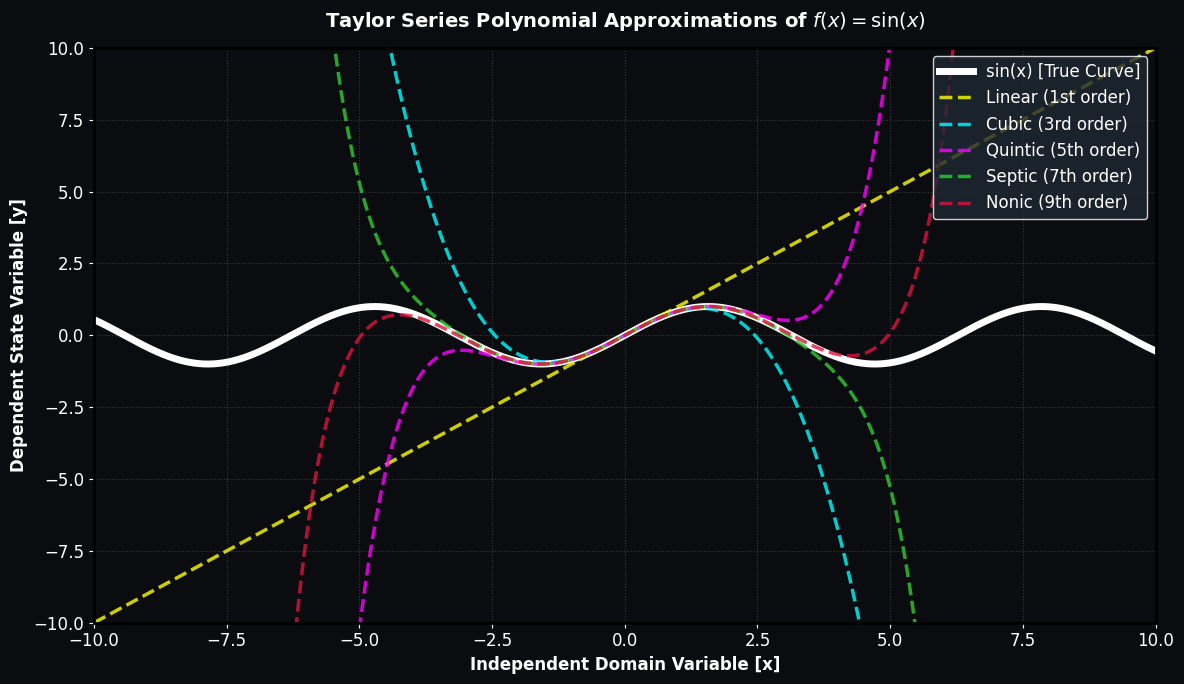

In [4]:
# =============================================================================
# NOTEBOOK STEP 3: GRAPHICAL ENGINE & RENDERING INTERFACE
# FIXED: Corrected the '---' line style typo to a standard '--'
# =============================================================================

fig, ax = plt.subplots()

# 1. Render the true target curve as a solid, prominent white baseline
ax.plot(x, y_true, color='#FFFFFF', linewidth=5, label='sin(x) [True Curve]', zorder=2)

# 2. Layer on our approximations using bright, distinct colors (FIXED: '--')
ax.plot(x, y_1, '--', color='yellow', alpha=0.8, label='Linear (1st order)')
ax.plot(x, y_3, '--', color='cyan', alpha=0.8, label='Cubic (3rd order)')
ax.plot(x, y_5, '--', color='magenta', alpha=0.8, label='Quintic (5th order)')
ax.plot(x, y_7, '--', color='limegreen', alpha=0.8, label='Septic (7th order)')
ax.plot(x, y_9, '--', color='crimson', alpha=0.8, label='Nonic (9th order)')

# 3. Canvas formatting modifications for dark-mode high contrast
ax.set_facecolor('#0B0C10')  # Dark presentation background
fig.patch.set_facecolor('#0B0C10')

# Match the lecture limits exactly
ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])

# Grid line specification
ax.grid(True, linestyle=":", color='gray', alpha=0.4)

# Spine coloration adjustments for dark mode readability
ax.spines['bottom'].color = 'white'
ax.spines['top'].color = 'white'
ax.spines['left'].color = 'white'
ax.spines['right'].color = 'white'
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')

# Titles and metadata labeling
ax.set_title("Taylor Series Polynomial Approximations of $f(x) = \\sin(x)$", color='white', pad=15, fontsize=14, fontweight='bold')
ax.set_xlabel("Independent Domain Variable [x]", fontweight='bold')
ax.set_ylabel("Dependent State Variable [y]", fontweight='bold')

# Legend layout customization
legend = ax.legend(loc='upper right', facecolor='#1F2833', edgecolor='white')
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

If you observe the output graph generated by Cell 5, you will notice three vital engineering principles:1. Local Accuracy vs. Global FailureRight around the center point ($x = 0$), every single line is completely accurate. Even the simple yellow straight line ($y = x$) tracks the true sine wave tightly between $x = -0.5$ and $x = 0.5$. This is why engineering models often use the "small-angle approximation" ($\sin(\theta) \approx \theta$) for subtle structural swings!2. The "Unpeeling" Convergence BehaviorAs you move outward from zero toward $x = \pm 4$ or $x = \pm 6$, lower-order approximations fail completely, snapping violently toward positive or negative infinity. This shows that a Taylor series does not approximate the entire function all at once; it grows outward from its anchor center point.3. The Power of Higher OrdersTo accurately model behavior further away from the anchor point, you must add higher-order terms. The 9th-order polynomial (the crimson line) successfully hugs the sine wave over a much wider span before it eventually yields and diverges.